In [1]:
import sys
import os
src_dir = "../../src"
if src_dir not in sys.path:
    sys.path.append(src_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from utils.error_report import get_error_from_list
from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, ErrorEnum, FilterEnum, NoiseTypeEnum
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter


%matplotlib inline
np.random.seed(777)

# Load raw data 0016 (sequence number 04)

Data size: 271
Shape:
GPS: (271, 3)
VO: (271, 3)
IMU: (271, 6)
INS angle: (271, 3)
INS velocity: (271, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Data sampling is set to normal mode.


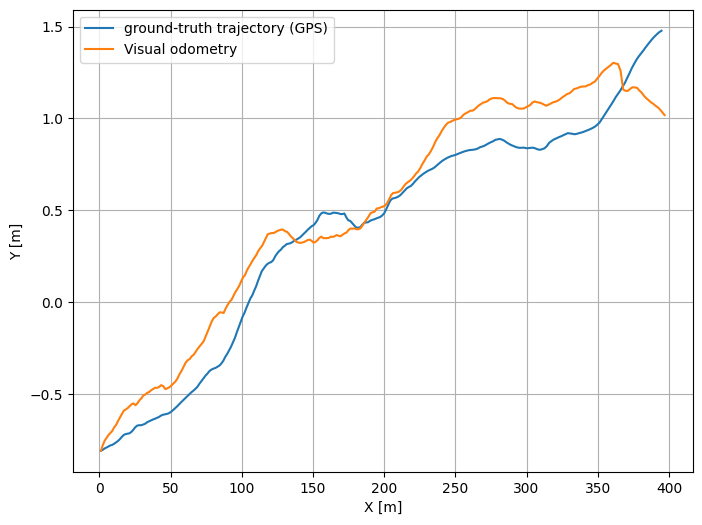

In [2]:
root_path = "../../"
file_export_path = os.path.join(root_path, "exports/_sequences/04")
kitti_root_dir = os.path.join(root_path, "data")
vo_root_dir = os.path.join(root_path, "vo_estimates")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
kitti_date = '2011_09_30'
kitti_drive = '0016'
noise_type = NoiseTypeEnum.CURRENT

data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  noise_vector_dir=noise_vector_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0)

## Display data with noise

### VO trajectory with noise

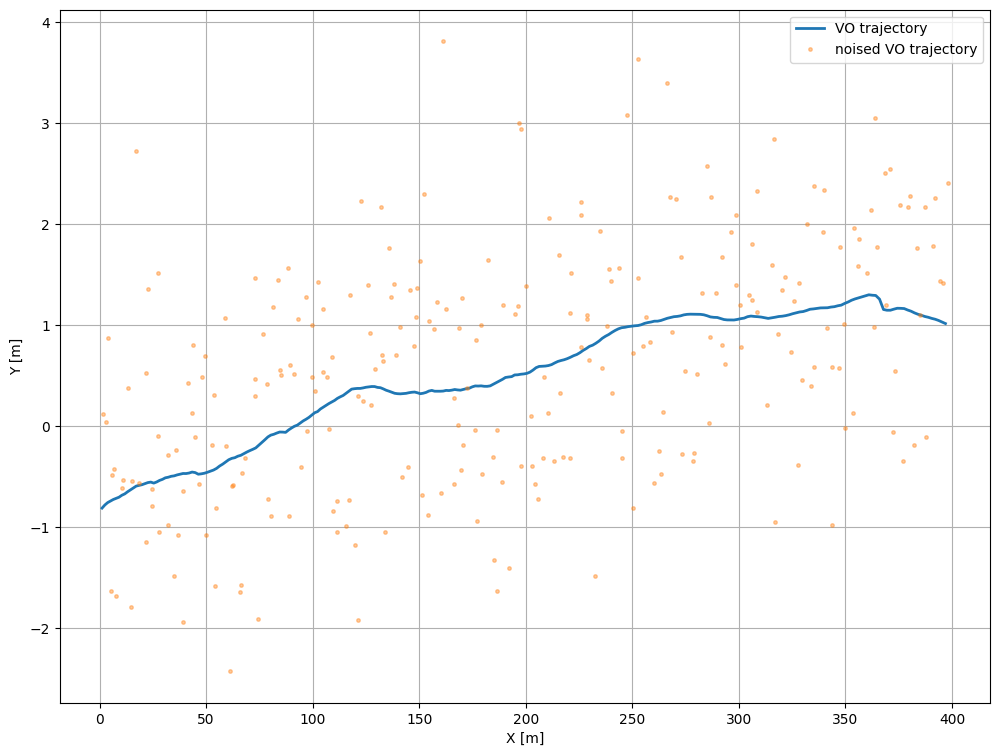

In [3]:
data.show_vo_with_noise()

### Linear acceleration with noise

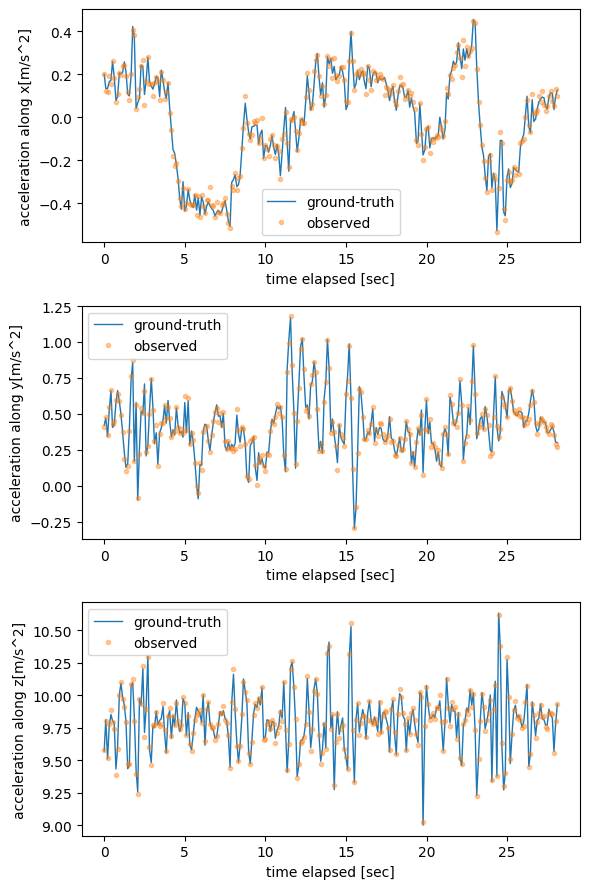

In [4]:
data.show_linear_acceleration_with_noise()

### Angular velocity with noise

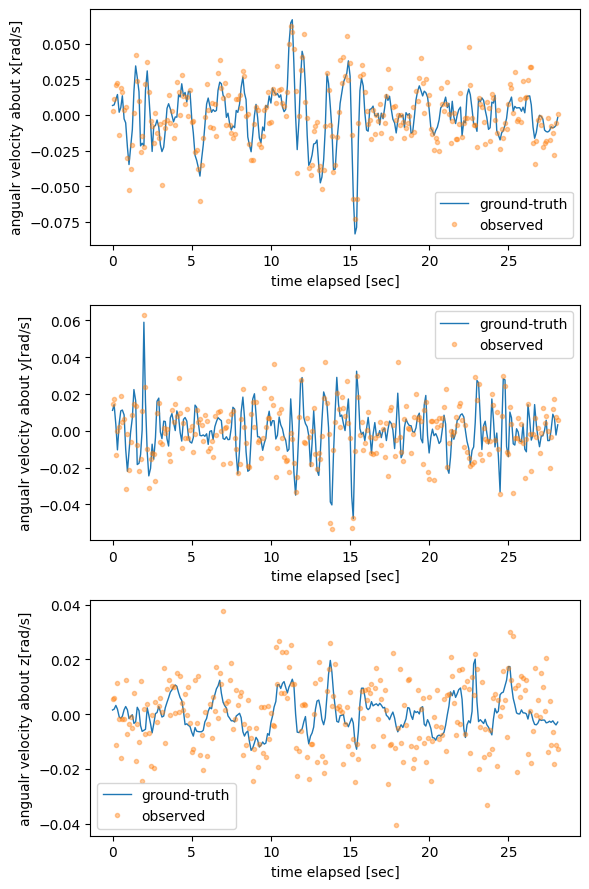

In [5]:
data.show_angular_velocity_with_noise()

### Linear velocity with noise

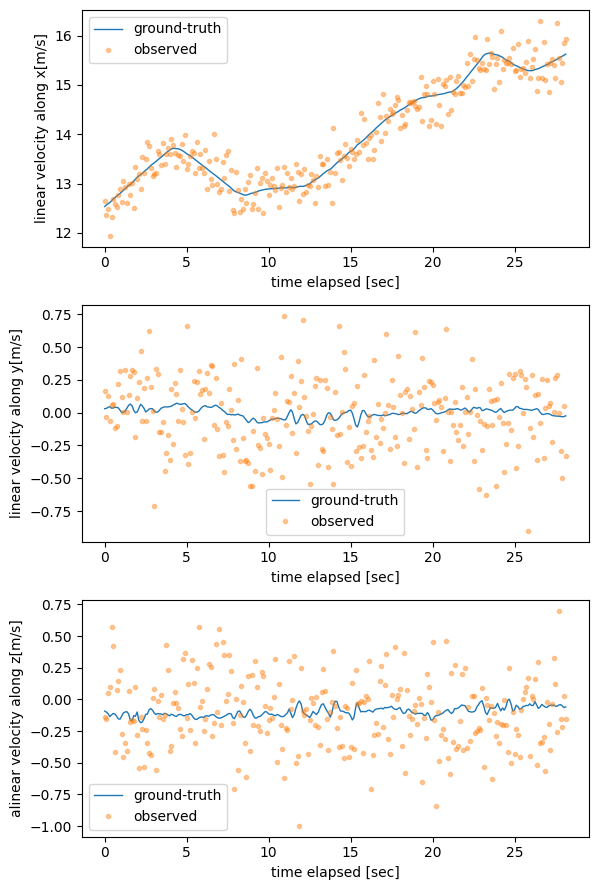

In [6]:
data.show_linear_velocity_with_noise()

# Applying filters

----

In [7]:
results_header = pd.MultiIndex.from_product([['Setup1 (IMU, VO)','Setup2(IMU, VO+GPS)', 'Setup3(INS, VO+INS)'],
                                             ['EKF', 'UKF', 'PF', 'EnKF', 'CKF']],
                                            names=['Setups','Filter types'])
df_dropout_indices = ['No dropout', '10% drop', '20% drop', '30% drop', '40% drop']

def get_error_dataframe(error_0, error_10, error_20, error_30, error_40):
    mae_0 = get_error_from_list(error_0, e_type=ErrorEnum.MAE)
    mae_10 = get_error_from_list(error_10, e_type=ErrorEnum.MAE)
    mae_20 = get_error_from_list(error_20, e_type=ErrorEnum.MAE)
    mae_30 = get_error_from_list(error_30, e_type=ErrorEnum.MAE)
    mae_40 = get_error_from_list(error_40, e_type=ErrorEnum.MAE)

    rmse_0 = get_error_from_list(error_0, e_type=ErrorEnum.RMSE)
    rmse_10 = get_error_from_list(error_10, e_type=ErrorEnum.RMSE)
    rmse_20 = get_error_from_list(error_20, e_type=ErrorEnum.RMSE)
    rmse_30 = get_error_from_list(error_30, e_type=ErrorEnum.RMSE)
    rmse_40 = get_error_from_list(error_40, e_type=ErrorEnum.RMSE)
    
    max_0 = get_error_from_list(error_0, e_type=ErrorEnum.MAX)
    max_10 = get_error_from_list(error_10, e_type=ErrorEnum.MAX)
    max_20 = get_error_from_list(error_20, e_type=ErrorEnum.MAX)
    max_30 = get_error_from_list(error_30, e_type=ErrorEnum.MAX)
    max_40 = get_error_from_list(error_40, e_type=ErrorEnum.MAX)
    
    mae_error = [mae_0, mae_10, mae_20, mae_30, mae_40]
    rmse_error = [rmse_0, rmse_10, rmse_20, rmse_30, rmse_40]
    max_error = [max_0, max_10, max_20, max_30, max_40]
    
    mae_df = pd.DataFrame(np.array(mae_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    rmse_df = pd.DataFrame(np.array(rmse_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    max_df = pd.DataFrame(np.array(max_error), 
                            index=df_dropout_indices, 
                            columns=results_header)
    
    return mae_df, rmse_df, max_df



In [8]:
errors_0 = []
errors_10 = []
errors_20 = []
errors_30 = []
errors_40 = []

# No measurement data drop

In [9]:
data.change_dropout_ratio(vo_dropout_ratio=0.0, gps_dropout_ratio=0.0)

In [10]:
alpha_setup1_0 = 1.0
beta_setup1_0 = 6.0
kappa_setup1_0 = -7.0

alpha_setup2_0 = 0.0001
beta_setup2_0 = 0.0
kappa_setup2_0 = 0.0

alpha_setup3_0 = 0.0001
beta_setup3_0 = 0.0
kappa_setup3_0 = 0.0

n_samples_setup1_0 = 2048
resampling_algorithm_setup1_0 = ResamplingAlgorithms.RESIDUAL
n_samples_setup2_0 = 2048
resampling_algorithm_setup2_0 = ResamplingAlgorithms.STRATIFIED
n_samples_setup3_0 = 2048
resampling_algorithm_setup3_0 = ResamplingAlgorithms.MULTINOMIAL

n_ensemble_setup1_0 = 32
n_ensemble_setup2_0 = 128
n_ensemble_setup3_0 = 64

## Setup1

In [11]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_0 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_0 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_0, 
  beta=beta_setup1_0, 
  kappa=kappa_setup1_0,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_0 = ParticleFilter(
  N=n_samples_setup1_0, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_0
)
pf1_0.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_0, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_0 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [12]:
error_ekf1_0 = ekf1_0.run(data=data, debug_mode=True)
error_ukf1_0 = ukf1_0.run(data=data, debug_mode=True)
error_pf1_0 = pf1_0.run(data=data, debug_mode=True)
error_enkf1_0 = enkf1_0.run(data=data, debug_mode=True)
error_ckf1_0 = ckf1_0.run(data=data, debug_mode=True)


errors_0.append(error_ekf1_0)
errors_0.append(error_ukf1_0)
errors_0.append(error_pf1_0)
errors_0.append(error_enkf1_0)
errors_0.append(error_ckf1_0)

[EKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 3169.76it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.684, <ErrorEnum.RMSE: 2>: 0.916, <ErrorEnum.MAX: 3>: 3.906}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 1806.80it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.906, <ErrorEnum.RMSE: 2>: 1.128, <ErrorEnum.MAX: 3>: 3.478}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.759, <ErrorEnum.RMSE: 2>: 0.963, <ErrorEnum.MAX: 3>: 3.309}
[EnKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 2629.37it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.155, <ErrorEnum.RMSE: 2>: 1.452, <ErrorEnum.MAX: 3>: 4.766}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 3370.57it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.91, <ErrorEnum.RMSE: 2>: 1.131, <ErrorEnum.MAX: 3>: 3.478}


## Setup2

In [13]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_0 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_0 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_0, 
    beta=beta_setup2_0, 
    kappa=kappa_setup2_0,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_0 = ParticleFilter(
  N=n_samples_setup2_0, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_0
)
pf2_0.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_0, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_0 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [14]:
error_ekf2_0 = ekf2_0.run(data=data, debug_mode=True)
error_ukf2_0 = ukf2_0.run(data=data, debug_mode=True)
error_pf2_0 = pf2_0.run(data=data, debug_mode=True)
error_enkf2_0 = enkf2_0.run(data=data, debug_mode=True)
error_ckf2_0 = ckf2_0.run(data=data, debug_mode=True)

errors_0.append(error_ekf2_0)
errors_0.append(error_ukf2_0)
errors_0.append(error_pf2_0)
errors_0.append(error_enkf2_0)
errors_0.append(error_ckf2_0)

[EKF] start.


100%|██████████████████████████████████████| 270/270 [00:00<00:00, 10197.58it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.446, <ErrorEnum.RMSE: 2>: 0.599, <ErrorEnum.MAX: 3>: 3.08}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 2243.11it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.568, <ErrorEnum.RMSE: 2>: 0.72, <ErrorEnum.MAX: 3>: 2.647}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.528, <ErrorEnum.RMSE: 2>: 0.672, <ErrorEnum.MAX: 3>: 1.953}
[EnKF] start.


100%|████████████████████████████████████████| 270/270 [00:00<00:00, 593.09it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 0.924, <ErrorEnum.RMSE: 2>: 1.187, <ErrorEnum.MAX: 3>: 3.262}
[CKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 2505.09it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.572, <ErrorEnum.RMSE: 2>: 0.725, <ErrorEnum.MAX: 3>: 2.646}


## Setup3

In [15]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_0 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_0 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_0, 
  beta=beta_setup3_0, 
  kappa=kappa_setup3_0,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_0 = ParticleFilter(
  N=n_samples_setup3_0, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_0
)
pf3_0.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_0, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_0 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [16]:
error_ekf3_0 = ekf3_0.run(data=data, debug_mode=True)
error_ukf3_0 = ukf3_0.run(data=data, debug_mode=True)
error_pf3_0 = pf3_0.run(data=data, debug_mode=True)
error_enkf3_0 = enkf3_0.run(data=data, debug_mode=True)
error_ckf3_0 = ckf3_0.run(data=data, debug_mode=True)

errors_0.append(error_ekf3_0)
errors_0.append(error_ukf3_0)
errors_0.append(error_pf3_0)
errors_0.append(error_enkf3_0)
errors_0.append(error_ckf3_0)

[EKF] start.


100%|██████████████████████████████████████| 270/270 [00:00<00:00, 18615.61it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.281, <ErrorEnum.RMSE: 2>: 0.336, <ErrorEnum.MAX: 3>: 0.911}
[UKF] start.


100%|███████████████████████████████████████| 270/270 [00:00<00:00, 5956.97it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.331, <ErrorEnum.RMSE: 2>: 0.413, <ErrorEnum.MAX: 3>: 1.246}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.268, <ErrorEnum.RMSE: 2>: 0.346, <ErrorEnum.MAX: 3>: 1.191}
[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 1461.24it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 0.776, <ErrorEnum.RMSE: 2>: 0.981, <ErrorEnum.MAX: 3>: 2.751}
[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 6402.03it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.331, <ErrorEnum.RMSE: 2>: 0.413, <ErrorEnum.MAX: 3>: 1.246}


# 10% drop

In [17]:
data.change_dropout_ratio(vo_dropout_ratio=0.1, gps_dropout_ratio=0.1)

In [18]:
alpha_setup1_10 = 0.0001
beta_setup1_10 = 0.0
kappa_setup1_10 = -7.0

alpha_setup2_10 = 0.0001
beta_setup2_10 = 4.0
kappa_setup2_10 = -7.0

alpha_setup3_10 = 0.0001
beta_setup3_10 = 0.0
kappa_setup3_10 = 0.0

n_samples_setup1_10 = 2048
resampling_algorithm_setup1_10 = ResamplingAlgorithms.STRATIFIED
n_samples_setup2_10 = 2048
resampling_algorithm_setup2_10 = ResamplingAlgorithms.RESIDUAL
n_samples_setup3_10 = 2048
resampling_algorithm_setup3_10 = ResamplingAlgorithms.RESIDUAL

n_ensemble_setup1_10 = 32
n_ensemble_setup2_10 = 128
n_ensemble_setup3_10 = 64

## Setup1

In [19]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_10 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_10 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_10, 
  beta=beta_setup1_10, 
  kappa=kappa_setup1_10,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_10 = ParticleFilter(
  N=n_samples_setup1_10, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_10
)
pf1_10.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_10, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_10 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [20]:
error_ekf1_10 = ekf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_10 = ukf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_10 = pf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf1_10 = enkf1_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_10 = ckf1_10.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_10.append(error_ekf1_10)
errors_10.append(error_ukf1_10)
errors_10.append(error_pf1_10)
errors_10.append(error_enkf1_10)
errors_10.append(error_ckf1_10)

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 13557.55it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.725, <ErrorEnum.RMSE: 2>: 0.956, <ErrorEnum.MAX: 3>: 3.906}
[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 3418.54it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.012, <ErrorEnum.RMSE: 2>: 1.26, <ErrorEnum.MAX: 3>: 3.659}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.773, <ErrorEnum.RMSE: 2>: 0.973, <ErrorEnum.MAX: 3>: 3.302}
[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2881.82it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.16, <ErrorEnum.RMSE: 2>: 1.445, <ErrorEnum.MAX: 3>: 5.235}
[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 3505.54it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.949, <ErrorEnum.RMSE: 2>: 1.181, <ErrorEnum.MAX: 3>: 3.52}


## Setup2

In [21]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_10 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_10 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_10, 
    beta=beta_setup2_10, 
    kappa=kappa_setup2_10,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_10 = ParticleFilter(
  N=n_samples_setup2_10, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_10
)
pf2_10.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_10, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_10 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [22]:
error_ekf2_10 = ekf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_10 = ukf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_10 = pf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf2_10 = enkf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_10 = ckf2_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_10.append(error_ekf2_10)
errors_10.append(error_ukf2_10)
errors_10.append(error_pf2_10)
errors_10.append(error_enkf2_10)
errors_10.append(error_ckf2_10)

[EKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 9580.57it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.468, <ErrorEnum.RMSE: 2>: 0.635, <ErrorEnum.MAX: 3>: 3.084}
[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2394.51it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.601, <ErrorEnum.RMSE: 2>: 0.759, <ErrorEnum.MAX: 3>: 2.646}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.551, <ErrorEnum.RMSE: 2>: 0.697, <ErrorEnum.MAX: 3>: 2.611}
[EnKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 641.58it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 0.99, <ErrorEnum.RMSE: 2>: 1.24, <ErrorEnum.MAX: 3>: 3.694}
[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2643.15it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.606, <ErrorEnum.RMSE: 2>: 0.767, <ErrorEnum.MAX: 3>: 2.646}


## Setup3

In [23]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_10 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_10 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_10, 
  beta=beta_setup3_10, 
  kappa=kappa_setup3_10,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_10 = ParticleFilter(
  N=n_samples_setup3_10, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_10
)
pf3_10.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_10 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_10, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_10 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [24]:
error_ekf3_10 = ekf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_10 = ukf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_10 = pf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf3_10 = enkf3_10.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_10 = ckf3_10.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_10.append(error_ekf3_10)
errors_10.append(error_ukf3_10)
errors_10.append(error_pf3_10)
errors_10.append(error_enkf3_10)
errors_10.append(error_ckf3_10)

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 19027.22it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.286, <ErrorEnum.RMSE: 2>: 0.349, <ErrorEnum.MAX: 3>: 0.976}
[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 6528.66it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.343, <ErrorEnum.RMSE: 2>: 0.433, <ErrorEnum.MAX: 3>: 1.343}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.265, <ErrorEnum.RMSE: 2>: 0.339, <ErrorEnum.MAX: 3>: 1.223}
[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 1605.99it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 0.802, <ErrorEnum.RMSE: 2>: 1.017, <ErrorEnum.MAX: 3>: 3.052}
[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 6659.43it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.343, <ErrorEnum.RMSE: 2>: 0.432, <ErrorEnum.MAX: 3>: 1.356}


# 20% drop

In [25]:
data.change_dropout_ratio(vo_dropout_ratio=0.2, gps_dropout_ratio=0.2)

In [26]:
alpha_setup1_20 = 0.0001
beta_setup1_20 = 10.0
kappa_setup1_20 = 0.0

alpha_setup2_20 = 0.0001
beta_setup2_20 = 2.0
kappa_setup2_20 = -7.0

alpha_setup3_20 = 0.0001
beta_setup3_20 = 0.0
kappa_setup3_20 = 0.0

n_samples_setup1_20 = 2048
resampling_algorithm_setup1_20 = ResamplingAlgorithms.RESIDUAL
n_samples_setup2_20 = 2048
resampling_algorithm_setup2_20 = ResamplingAlgorithms.RESIDUAL
n_samples_setup3_20 = 2048
resampling_algorithm_setup3_20 = ResamplingAlgorithms.MULTINOMIAL

n_ensemble_setup1_20 = 32
n_ensemble_setup2_20 = 64
n_ensemble_setup3_20 = 128

## Setup1

In [27]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_20 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_20 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_20, 
  beta=beta_setup1_20, 
  kappa=kappa_setup1_20,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_20 = ParticleFilter(
  N=n_samples_setup1_20, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_20
)
pf1_20.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_20, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_20 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [28]:
error_ekf1_20 = ekf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_20 = ukf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_20 = pf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf1_20 = enkf1_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_20 = ckf1_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_20.append(error_ekf1_20)
errors_20.append(error_ukf1_20)
errors_20.append(error_pf1_20)
errors_20.append(error_enkf1_20)
errors_20.append(error_ckf1_20)

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 13497.92it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.772, <ErrorEnum.RMSE: 2>: 1.073, <ErrorEnum.MAX: 3>: 5.574}
[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 3551.73it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.078, <ErrorEnum.RMSE: 2>: 1.35, <ErrorEnum.MAX: 3>: 4.141}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.802, <ErrorEnum.RMSE: 2>: 1.012, <ErrorEnum.MAX: 3>: 3.024}
[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 3010.57it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.221, <ErrorEnum.RMSE: 2>: 1.506, <ErrorEnum.MAX: 3>: 5.808}
[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 3703.91it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.066, <ErrorEnum.RMSE: 2>: 1.345, <ErrorEnum.MAX: 3>: 4.139}


## Setup2

In [29]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_20 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_20 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_20, 
    beta=beta_setup2_20, 
    kappa=kappa_setup2_20,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_20 = ParticleFilter(
  N=n_samples_setup2_20, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_20
)
pf2_20.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_20, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_20 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [30]:
error_ekf2_20 = ekf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_20 = ukf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_20 = pf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf2_20 = enkf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_20 = ckf2_20.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_20.append(error_ekf2_20)
errors_20.append(error_ukf2_20)
errors_20.append(error_pf2_20)
errors_20.append(error_enkf2_20)
errors_20.append(error_ckf2_20)

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 11141.35it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.503, <ErrorEnum.RMSE: 2>: 0.67, <ErrorEnum.MAX: 3>: 3.657}
[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2635.69it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.659, <ErrorEnum.RMSE: 2>: 0.817, <ErrorEnum.MAX: 3>: 2.927}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.613, <ErrorEnum.RMSE: 2>: 0.782, <ErrorEnum.MAX: 3>: 2.841}
[EnKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 832.17it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.027, <ErrorEnum.RMSE: 2>: 1.319, <ErrorEnum.MAX: 3>: 4.863}
[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2496.53it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.658, <ErrorEnum.RMSE: 2>: 0.82, <ErrorEnum.MAX: 3>: 2.927}


## Setup3

In [31]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_20 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_20 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_20, 
  beta=beta_setup3_20, 
  kappa=kappa_setup3_20,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_20 = ParticleFilter(
  N=n_samples_setup3_20, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_20
)
pf3_20.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_20 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_20, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_20 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [32]:
error_ekf3_20 = ekf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_20 = ukf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_20 = pf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf3_20 = enkf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_20 = ckf3_20.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_20.append(error_ekf3_20)
errors_20.append(error_ukf3_20)
errors_20.append(error_pf3_20)
errors_20.append(error_enkf3_20)
errors_20.append(error_ckf3_20)

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 17859.36it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.294, <ErrorEnum.RMSE: 2>: 0.364, <ErrorEnum.MAX: 3>: 1.011}
[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 6897.60it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.364, <ErrorEnum.RMSE: 2>: 0.45, <ErrorEnum.MAX: 3>: 1.396}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.311, <ErrorEnum.RMSE: 2>: 0.402, <ErrorEnum.MAX: 3>: 1.191}
[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 1050.30it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 0.828, <ErrorEnum.RMSE: 2>: 1.055, <ErrorEnum.MAX: 3>: 3.498}
[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 7654.36it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.364, <ErrorEnum.RMSE: 2>: 0.45, <ErrorEnum.MAX: 3>: 1.391}


# 30% drop

In [33]:
data.change_dropout_ratio(vo_dropout_ratio=0.3, gps_dropout_ratio=0.3)

In [34]:
alpha_setup1_30 = 0.001
beta_setup1_30 = 0.0
kappa_setup1_30 = -7.0

alpha_setup2_30 = 0.0001
beta_setup2_30 = 8.0
kappa_setup2_30 = 0.0

alpha_setup3_30 = 0.0001
beta_setup3_30 = 0.0
kappa_setup3_30 = 0.0

n_samples_setup1_30 = 2048
resampling_algorithm_setup1_30 = ResamplingAlgorithms.MULTINOMIAL
n_samples_setup2_30 = 2048
resampling_algorithm_setup2_30 = ResamplingAlgorithms.MULTINOMIAL
n_samples_setup3_30 = 2048
resampling_algorithm_setup3_30 = ResamplingAlgorithms.RESIDUAL

n_ensemble_setup1_30 = 64
n_ensemble_setup2_30 = 128
n_ensemble_setup3_30 = 32

## Setup1

In [35]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_30 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_30 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_30, 
  beta=beta_setup1_30, 
  kappa=kappa_setup1_30,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_30 = ParticleFilter(
  N=n_samples_setup1_30, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_30
)
pf1_30.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_30, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_30 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 13173.98it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.765, <ErrorEnum.RMSE: 2>: 1.028, <ErrorEnum.MAX: 3>: 5.165}
[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 3709.05it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.048, <ErrorEnum.RMSE: 2>: 1.342, <ErrorEnum.MAX: 3>: 5.624}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.874, <ErrorEnum.RMSE: 2>: 1.091, <ErrorEnum.MAX: 3>: 3.437}
[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 1939.15it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.328, <ErrorEnum.RMSE: 2>: 1.639, <ErrorEnum.MAX: 3>: 5.616}
[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 3516.49it/s]


[CKF] errors: {<ErrorEnum.MAE: 1>: 0.91, <ErrorEnum.RMSE: 2>: 1.131, <ErrorEnum.MAX: 3>: 3.478}


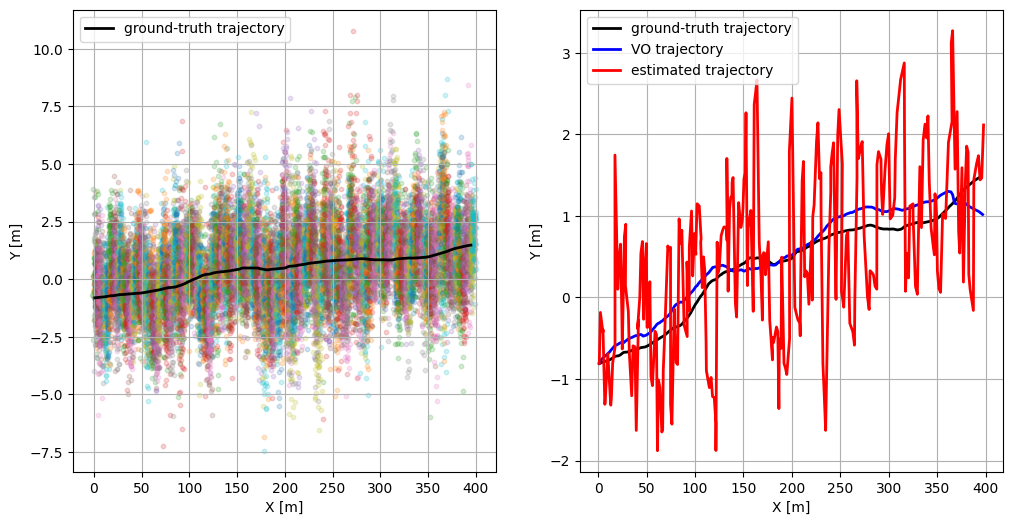

In [36]:
error_ekf1_30 = ekf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_30 = ukf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_30 = pf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True,
    show_graph=True
)
error_enkf1_30 = enkf1_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_30 = ckf1_30.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_30.append(error_ekf1_30)
errors_30.append(error_ukf1_30)
errors_30.append(error_pf1_30)
errors_30.append(error_enkf1_30)
errors_30.append(error_ckf1_30)

## Setup2

In [37]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_30 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_30 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_30, 
    beta=beta_setup2_30, 
    kappa=kappa_setup2_30,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_30 = ParticleFilter(
  N=n_samples_setup2_30, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_30
)
pf2_30.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_30, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_30 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [38]:
error_ekf2_30 = ekf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_30 = ukf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_30 = pf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf2_30 = enkf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_30 = ckf2_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)

errors_30.append(error_ekf2_30)
errors_30.append(error_ukf2_30)
errors_30.append(error_pf2_30)
errors_30.append(error_enkf2_30)
errors_30.append(error_ckf2_30)

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 14089.56it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.765, <ErrorEnum.RMSE: 2>: 1.028, <ErrorEnum.MAX: 3>: 5.165}
[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2728.51it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.66, <ErrorEnum.RMSE: 2>: 0.852, <ErrorEnum.MAX: 3>: 3.374}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.634, <ErrorEnum.RMSE: 2>: 0.823, <ErrorEnum.MAX: 3>: 3.326}
[EnKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 753.70it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.051, <ErrorEnum.RMSE: 2>: 1.321, <ErrorEnum.MAX: 3>: 4.381}
[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2931.56it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.659, <ErrorEnum.RMSE: 2>: 0.856, <ErrorEnum.MAX: 3>: 3.374}


## Setup3

In [39]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_30 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_30 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_30, 
  beta=beta_setup3_30, 
  kappa=kappa_setup3_30,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_30 = ParticleFilter(
  N=n_samples_setup3_30, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_30
)
pf3_30.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_30 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_30, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_30 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [40]:
error_ekf3_30 = ekf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_30 = ukf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_30 = pf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf3_30 = enkf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_30 = ckf3_30.run(
    data=data, 
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)


errors_30.append(error_ekf3_30)
errors_30.append(error_ukf3_30)
errors_30.append(error_pf3_30)
errors_30.append(error_enkf3_30)
errors_30.append(error_ckf3_30)

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 21103.22it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.312, <ErrorEnum.RMSE: 2>: 0.37, <ErrorEnum.MAX: 3>: 1.004}
[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 7676.77it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.365, <ErrorEnum.RMSE: 2>: 0.456, <ErrorEnum.MAX: 3>: 1.334}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.341, <ErrorEnum.RMSE: 2>: 0.434, <ErrorEnum.MAX: 3>: 1.545}
[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 3068.50it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 0.83, <ErrorEnum.RMSE: 2>: 1.054, <ErrorEnum.MAX: 3>: 3.93}
[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 7930.24it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.364, <ErrorEnum.RMSE: 2>: 0.456, <ErrorEnum.MAX: 3>: 1.338}


# 40% drop

In [41]:
data.change_dropout_ratio(vo_dropout_ratio=0.4, gps_dropout_ratio=0.4)

In [42]:
alpha_setup1_40 = 1.0
beta_setup1_40 = 10.0
kappa_setup1_40 = -7.0

alpha_setup2_40 = 0.2
beta_setup2_40 = 8.0
kappa_setup2_40 = 0.0

alpha_setup3_40 = 0.0001
beta_setup3_40 = 2.0
kappa_setup3_40 = 0.0

n_samples_setup1_40 = 2048
resampling_algorithm_setup1_40 = ResamplingAlgorithms.SYSTEMATIC
n_samples_setup2_40 = 2048
resampling_algorithm_setup2_40 = ResamplingAlgorithms.RESIDUAL
n_samples_setup3_40 = 2048
resampling_algorithm_setup3_40 = ResamplingAlgorithms.STRATIFIED

n_ensemble_setup1_40 = 64
n_ensemble_setup2_40 = 64
n_ensemble_setup3_40 = 32

## Setup1

In [43]:
setup = SetupEnum.SETUP_1

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf1_40 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf1_40 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_40, 
  beta=beta_setup1_40, 
  kappa=kappa_setup1_40,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_40 = ParticleFilter(
  N=n_samples_setup1_40, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_40
)
pf1_40.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf1_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_40, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_40 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=setup,
)

In [44]:
error_ekf1_40 = ekf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf1_40 = ukf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf1_40 = pf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf1_40 = enkf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf1_40 = ckf1_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True,
)

errors_40.append(error_ekf1_40)
errors_40.append(error_ukf1_40)
errors_40.append(error_pf1_40)
errors_40.append(error_enkf1_40)
errors_40.append(error_ckf1_40)

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 14638.86it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.791, <ErrorEnum.RMSE: 2>: 1.108, <ErrorEnum.MAX: 3>: 6.841}
[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 3804.79it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 1.442, <ErrorEnum.RMSE: 2>: 1.979, <ErrorEnum.MAX: 3>: 6.73}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.869, <ErrorEnum.RMSE: 2>: 1.081, <ErrorEnum.MAX: 3>: 4.582}
[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2036.66it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.223, <ErrorEnum.RMSE: 2>: 1.541, <ErrorEnum.MAX: 3>: 6.979}
[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 4163.52it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.468, <ErrorEnum.RMSE: 2>: 1.997, <ErrorEnum.MAX: 3>: 6.746}


## Setup2

In [45]:
setup = SetupEnum.SETUP_2

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_40 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf2_40 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_40, 
    beta=beta_setup2_40, 
    kappa=kappa_setup2_40,
    setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_40 = ParticleFilter(
  N=n_samples_setup2_40, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_40
)
pf2_40.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_40, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf2_40 = CubatureKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
)

In [46]:
error_ekf2_40 = ekf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf2_40 = ukf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf2_40 = pf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf2_40 = enkf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf2_40 = ckf2_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_40.append(error_ekf2_40)
errors_40.append(error_ukf2_40)
errors_40.append(error_pf2_40)
errors_40.append(error_enkf2_40)
errors_40.append(error_ckf2_40)

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 12059.53it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.541, <ErrorEnum.RMSE: 2>: 0.76, <ErrorEnum.MAX: 3>: 4.454}
[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2981.25it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.782, <ErrorEnum.RMSE: 2>: 1.021, <ErrorEnum.MAX: 3>: 3.973}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.716, <ErrorEnum.RMSE: 2>: 0.933, <ErrorEnum.MAX: 3>: 3.097}
[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 1479.12it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 1.071, <ErrorEnum.RMSE: 2>: 1.37, <ErrorEnum.MAX: 3>: 4.897}
[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 3268.97it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.775, <ErrorEnum.RMSE: 2>: 1.016, <ErrorEnum.MAX: 3>: 3.964}


## Setup3

In [47]:
setup = SetupEnum.SETUP_3

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf3_40 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)
ukf3_40 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_40, 
  beta=beta_setup3_40, 
  kappa=kappa_setup3_40,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf3_40 = ParticleFilter(
  N=n_samples_setup3_40, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_40
)
pf3_40.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf3_40 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_40, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf3_40 = CubatureKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

In [48]:
error_ekf3_40 = ekf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ukf3_40 = ukf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_pf3_40 = pf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_enkf3_40 = enkf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT,
    debug_mode=True
)
error_ckf3_40 = ckf3_40.run(
    data=data,
    measurement_type=MeasurementDataEnum.DROPOUT, 
    debug_mode=True
)


errors_40.append(error_ekf3_40)
errors_40.append(error_ukf3_40)
errors_40.append(error_pf3_40)
errors_40.append(error_enkf3_40)
errors_40.append(error_ckf3_40)

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 22813.96it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 0.277, <ErrorEnum.RMSE: 2>: 0.357, <ErrorEnum.MAX: 3>: 1.19}
[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 8526.48it/s]


[UKF] errors: {<ErrorEnum.MAE: 1>: 0.387, <ErrorEnum.RMSE: 2>: 0.492, <ErrorEnum.MAX: 3>: 1.505}
[PF] start.


...

[PF] errors: {<ErrorEnum.MAE: 1>: 0.377, <ErrorEnum.RMSE: 2>: 0.477, <ErrorEnum.MAX: 3>: 1.581}
[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 3513.01it/s]


[EnKF] errors: {<ErrorEnum.MAE: 1>: 0.881, <ErrorEnum.RMSE: 2>: 1.118, <ErrorEnum.MAX: 3>: 3.811}
[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 8369.02it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 0.386, <ErrorEnum.RMSE: 2>: 0.491, <ErrorEnum.MAX: 3>: 1.506}


# Results

In [49]:
mae_df, rmse_df, max_df = get_error_dataframe(errors_0, errors_10, errors_20, errors_30, errors_40)

In [50]:
mae_df

Setups       Setup1 (IMU, VO)                             Setup2(IMU, VO+GPS)  \
Filter types              EKF    UKF     PF   EnKF    CKF                 EKF   
No dropout              0.684  0.906  0.759  1.155  0.910               0.446   
10% drop                0.725  1.012  0.773  1.160  0.949               0.468   
20% drop                0.772  1.078  0.802  1.221  1.066               0.503   
30% drop                0.765  1.048  0.874  1.328  0.910               0.765   
40% drop                0.791  1.442  0.869  1.223  1.468               0.541   

Setups                                   Setup3(INS, VO+INS)                \
Filter types    UKF     PF   EnKF    CKF                 EKF    UKF     PF   
No dropout    0.568  0.528  0.924  0.572               0.281  0.331  0.268   
10% drop      0.601  0.551  0.990  0.606               0.286  0.343  0.265   
20% drop      0.659  0.613  1.027  0.658               0.294  0.364  0.311   
30% drop      0.660  0.634  1.051  0.659               0.312  0.365  0.341   
40% drop      0.782  0.716  1.071  0.775               0.277  0.387  0.377   

Setups                      
Filter types   EnKF    CKF  
No dropout    0.776  0.331  
10% drop      0.802  0.343  
20% drop      0.828  0.364  
30% drop      0.830  0.364  
40% drop      0.881  0.386

In [51]:
rmse_df

Setups       Setup1 (IMU, VO)                             Setup2(IMU, VO+GPS)  \
Filter types              EKF    UKF     PF   EnKF    CKF                 EKF   
No dropout              0.916  1.128  0.963  1.452  1.131               0.599   
10% drop                0.956  1.260  0.973  1.445  1.181               0.635   
20% drop                1.073  1.350  1.012  1.506  1.345               0.670   
30% drop                1.028  1.342  1.091  1.639  1.131               1.028   
40% drop                1.108  1.979  1.081  1.541  1.997               0.760   

Setups                                   Setup3(INS, VO+INS)                \
Filter types    UKF     PF   EnKF    CKF                 EKF    UKF     PF   
No dropout    0.720  0.672  1.187  0.725               0.336  0.413  0.346   
10% drop      0.759  0.697  1.240  0.767               0.349  0.433  0.339   
20% drop      0.817  0.782  1.319  0.820               0.364  0.450  0.402   
30% drop      0.852  0.823  1.321  0.856               0.370  0.456  0.434   
40% drop      1.021  0.933  1.370  1.016               0.357  0.492  0.477   

Setups                      
Filter types   EnKF    CKF  
No dropout    0.981  0.413  
10% drop      1.017  0.432  
20% drop      1.055  0.450  
30% drop      1.054  0.456  
40% drop      1.118  0.491

In [52]:
max_df

Setups       Setup1 (IMU, VO)                             Setup2(IMU, VO+GPS)  \
Filter types              EKF    UKF     PF   EnKF    CKF                 EKF   
No dropout              3.906  3.478  3.309  4.766  3.478               3.080   
10% drop                3.906  3.659  3.302  5.235  3.520               3.084   
20% drop                5.574  4.141  3.024  5.808  4.139               3.657   
30% drop                5.165  5.624  3.437  5.616  3.478               5.165   
40% drop                6.841  6.730  4.582  6.979  6.746               4.454   

Setups                                   Setup3(INS, VO+INS)                \
Filter types    UKF     PF   EnKF    CKF                 EKF    UKF     PF   
No dropout    2.647  1.953  3.262  2.646               0.911  1.246  1.191   
10% drop      2.646  2.611  3.694  2.646               0.976  1.343  1.223   
20% drop      2.927  2.841  4.863  2.927               1.011  1.396  1.191   
30% drop      3.374  3.326  4.381  3.374               1.004  1.334  1.545   
40% drop      3.973  3.097  4.897  3.964               1.190  1.505  1.581   

Setups                      
Filter types   EnKF    CKF  
No dropout    2.751  1.246  
10% drop      3.052  1.356  
20% drop      3.498  1.391  
30% drop      3.930  1.338  
40% drop      3.811  1.506

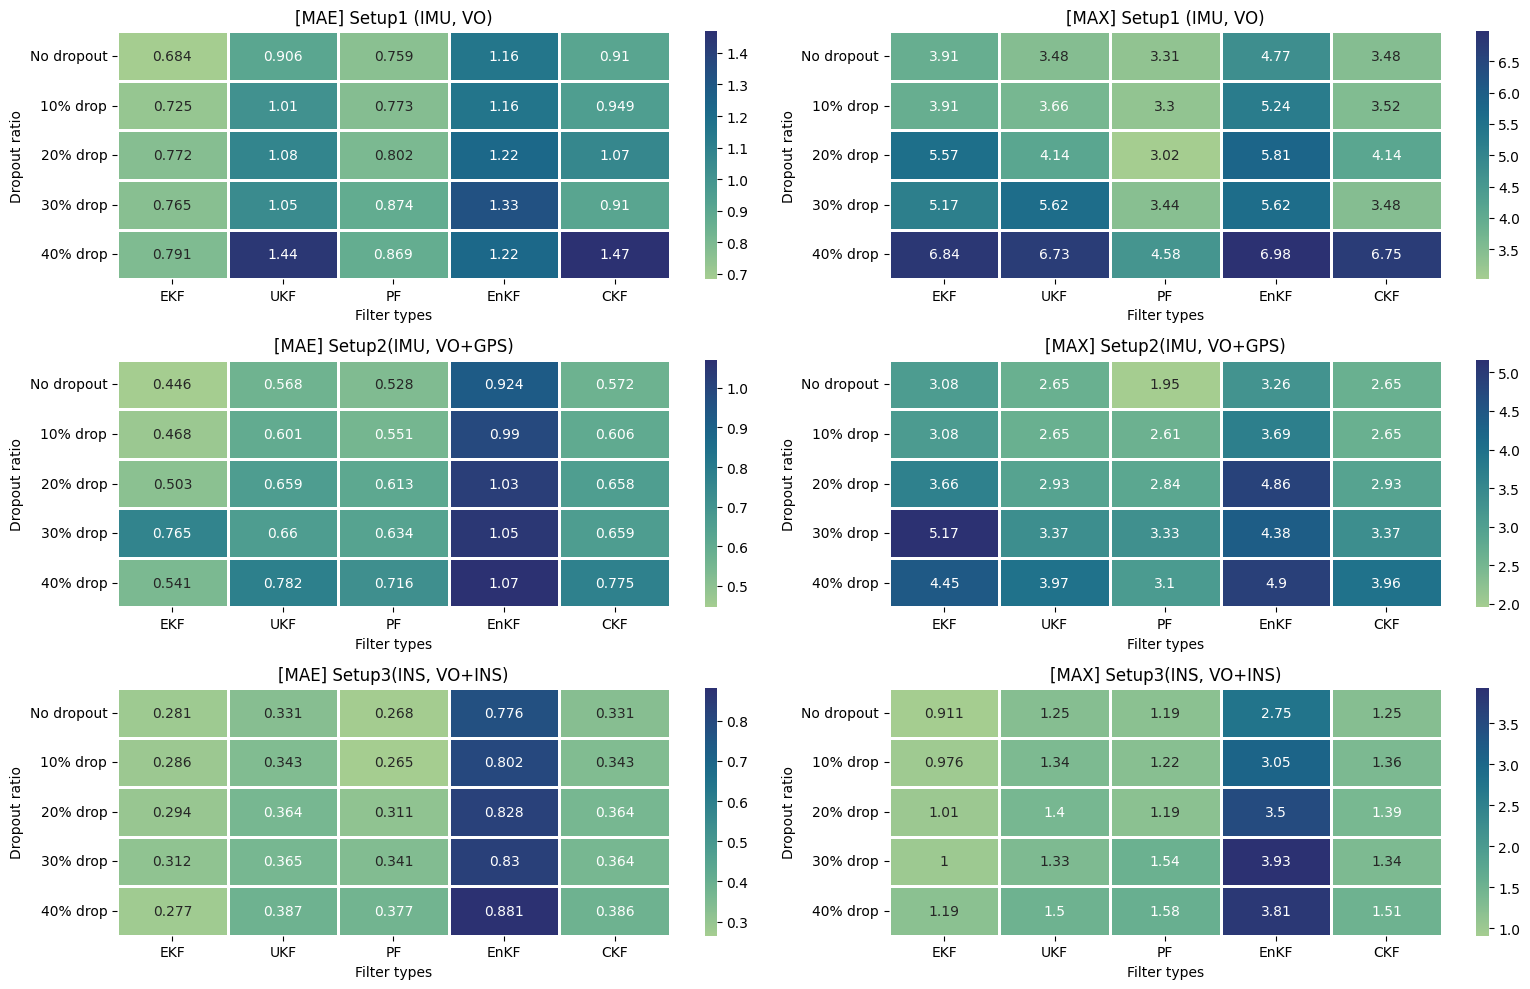

In [53]:
fig, (ax1_, ax2_, ax3_) = plt.subplots(nrows=3, ncols=2, figsize=(16, 10))
ax1, ax2 = ax1_[0], ax1_[1]
ax3, ax4 = ax2_[0], ax2_[1]
ax5, ax6 = ax3_[0], ax3_[1]

sns.heatmap(mae_df["Setup1 (IMU, VO)"],
            ax=ax1,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax1.set_title("[MAE] Setup1 (IMU, VO)")
ax1.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(mae_df["Setup2(IMU, VO+GPS)"],
            ax=ax3,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax3.set_title("[MAE] Setup2(IMU, VO+GPS)")
ax3.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(mae_df["Setup3(INS, VO+INS)"],
            ax=ax5,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax5.set_title("[MAE] Setup3(INS, VO+INS)")
ax5.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup1 (IMU, VO)"],
            ax=ax2,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax2.set_title("[MAX] Setup1 (IMU, VO)")
ax2.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup2(IMU, VO+GPS)"],
            ax=ax4,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax4.set_title("[MAX] Setup2(IMU, VO+GPS)")
ax4.set(xlabel="Filter types", ylabel="Dropout ratio")

sns.heatmap(max_df["Setup3(INS, VO+INS)"],
            ax=ax6,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax6.set_title("[MAX] Setup3(INS, VO+INS)")
ax6.set(xlabel="Filter types", ylabel="Dropout ratio")

fig.tight_layout()

In [54]:
mae_df.to_json(os.path.join(file_export_path, "pf_guaranteed_mae_df.json"))
rmse_df.to_json(os.path.join(file_export_path, "pf_guaranteed_rmse_df.json"))
max_df.to_json(os.path.join(file_export_path, "pf_guaranteed_max_df.json"))

# Conclusion

In this notebook, Kitti dataset sequeence number 4 is utilized to test all the implemented filters. Moreover, all the filters are tested for each setup with respect to measurement dropout ratio. To avoid filter divergence, particle filter has 2048 particles to approximate the posterior density.

In the setup 1, where IMU control input and VO measurement data are used, EKF provides the best result in MAE. However, the maximum error growth with respect the increase of dropout ratio of the Particle filter is les than the other filters and the difference of MAE between EKF and PF is negligible. Therefore, PF is the best result acheived in this setup.

In the setup 2, where IMU control input, VO and GPS measurement data are used, similar to the setup 1, PF has less growth of maximum error with respect to increase of dropout ratio in measurement data, PF has the best result than the other filters. 

In the setup 3, where INS control input and VO and INS measurement data are used, EKF outputs the best result in both MAE and maximum error in the trajectory.

The trajectory of the Kitti dataset sequence number 4 is straight line, in which the small amount of rotation is observed. Therefore, EKF's the first-order approximation on the systems model is strong enough the express the posterior density of the system, resulting in EKF performs well in this dataset.